# Projection matrix generation for SPECT with GATE 10

This notebook provides a practical demonstration of **projection matrix generation for SPECT using GATE 10**.  
The main input is a **DICOM file containing an attenuation map**, from which the simulation geometry is constructed.  
For demonstration purposes, the notebook also includes example data from an **anthropomorphic thyroid phantom**, including both the attenuation map and a corresponding SPECT acquisition.

The notebook is intended as an accessible starting point for researchers who wish to:
- generate projection matrices from attenuation-map data,
- test Monte Carlo-based SPECT modelling in a transparent workflow,
- and explore reconstruction pipelines that combine GATE simulation with modern computational tools.

This notebook is shared in the spirit of openness and reproducibility, with the aim of supporting wider uptake of Monte Carlo-based, patient-informed SPECT modelling within the medical imaging community.

---

## Funding and project context

This work is supported by the **Cyprus Research and Innovation Foundation** through the project **“Personalized SPECT” (PERSPECT)**  
(**Project No. EXCELLENCE/0524/0410**).  
The PERSPECT project is implemented within the framework of the **Cohesion Policy Programme “THALIA 2021–2027”** and is **co-funded by the European Union**.

The attenuation map and SPECT acquisition provided in this notebook were obtained using an **anthropomorphic thyroid phantom** within the project **SPECT_THYROID**,  
co-funded by the **European Regional Development Fund** and the **Republic of Cyprus** through the **Research and Innovation Foundation**  
(**Project No. EXCELLENCE/1216/0088**).

---

## Contents of the project directory

- **`PERSPECT_GATE10.ipynb`**
  The project notebook

- **`GATE10.py`**  
  Main GATE 10 simulation script used for projection-matrix generation.

- **`ATTMAPTOMOCT_EM001_DS.dcm`**  
  DICOM file containing the attenuation map of the anthropomorphic thyroid phantom.

- **`TOMOCT_EM001_DS.dcm`**  
  DICOM file containing the measured gamma-camera acquisition from the anthropomorphic thyroid phantom.

---

## Notes

### 1. Computational setup
At present, the OpenGATE workflow used here is configured to run **one simulation per projection angle**, and the demonstration is set up with a **low source activity (1 MBq)** in order to keep execution practical in Google Colab.

For realistic or large-scale applications, users are encouraged to:
- increase the simulated activity,
- adapt the workflow for batch execution over many projection angles,
- and use more advanced parallel execution strategies where possible.

### 2. Reconstruction
For the reconstruction stage shown in the final section, **GPU acceleration is strongly recommended**.  
In practice, the **free GPU resources available in Google Colab are sufficient for demonstration and testing purposes**, and can substantially accelerate reconstruction compared with CPU-only execution.

---

## Contact and collaboration

For questions regarding the notebook, the simulation workflow, or possible research collaboration, please contact:

**Dr Theodoros Leontiou**  
Associate Professor  
Department of Mechanical Engineering  
Frederick University, Cyprus  

Email: **t.leontiou@frederick.ac.cy**

This notebook is shared as part of the dissemination activities of the **PERSPECT** project ([PERSPECT website](https://perspect.frederick.ac.cy)), with the goal of promoting transparent, reproducible, and practically useful research in advanced SPECT simulation and reconstruction.

If this notebook contributes to your work, please consider citing one or more of the following related publications:

- Leontiou, T., Frixou, A., Ttofi, E., Chrysostomou, C., Parpottas, Y., and Michael, K.  
  *Hamiltonian dynamics for stochastic reconstruction in emission tomography*.  
  arXiv preprint **arXiv:2603.15070**, 2026.

- Frixou, A. , Leontiou, T., Stiliaris, E., and Papanicolas, C. N.  
  *Standardized Images and Evaluation Metrics for Tomography*.  
  Tomography 12(4):49, 2026.  
  DOI: 10.3390/tomography12040049
  arXiv preprint arXiv:2601.07531, 2026.

- Michael, K., Frangos, S., Iakovou, I., Lontos, A., Demosthenous, G., and Parpottas, Y.  
  *The Impact of Dual and Triple Energy Window Scatter Correction on I-123 Postsurgical Thyroid SPECT/CT Imaging Using a Phantom with Small Sizes of Thyroid Remnants*.  
  Life 14(1):113, 2024.  
  DOI: 10.3390/life14010113


## Quick start

To run this notebook:

1. Open the notebook.
2. Define the project folder PROJECT_PATH.
3. Make sure the project files are available in the selected project directory.
4. Run the setup cells to install dependencies and import the required modules.
5. Load the attenuation-map DICOM file and generate the `.mhd/.raw` files.
6. Run the GATE simulation over the selected projection angles.
7. Assemble the projection matrix and test reconstruction in the final section.

### Expected outputs
The notebook generates:
- a segmented attenuation map in `.mhd/.raw` format,
- a source mask in `.mhd/.raw` format,
- per-angle GATE outputs,
- a GATE-based projection matrix,
- and example MLEM reconstructions.

# General Definitions

*The notebook expects the project files to be available in PROJECT_PATH*

In [1]:
PROJECT_PATH = "./"
ATTENUATION_DICOM = f"{PROJECT_PATH}/ATTMAPTOMOCT_EM001_DS.dcm"
EMISSION_DICOM = f"{PROJECT_PATH}/TOMOCT_EM001_DS.dcm"
MU_MAP_PREFIX = f"{PROJECT_PATH}/mu_map"
SOURCE_MAP_PREFIX = f"{PROJECT_PATH}/source_map"
OUTPUT_BASE = PROJECT_PATH

In [2]:
from pathlib import Path

required_files = [
    f"{PROJECT_PATH}/GATE10.py",
    f"{PROJECT_PATH}/ATTMAPTOMOCT_EM001_DS.dcm",
    f"{PROJECT_PATH}/TOMOCT_EM001_DS.dcm",
]

for f in required_files:
    if not Path(f).exists():
        raise FileNotFoundError(f"Required file not found: {f}")

print("All required files found.")

All required files found.


In [3]:
pip install --upgrade opengate

  Using cached opengate-10.1.0-py3-none-any.whl.metadata (5.1 kB)
INFO: pip is looking at multiple versions of opengate to determine which version is compatible with other requirements. This could take a while.
  Using cached opengate-10.0.3-py3-none-any.whl.metadata (14 kB)
  Using cached opengate-10.0.2-py3-none-any.whl.metadata (14 kB)
  Using cached opengate-10.0.1-py3-none-any.whl.metadata (14 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install pydicom opengate uproot awkward tensorflow scikit-image

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import uproot, awkward as ak
import tensorflow as tf
import time
import sys
sys.path.append(PROJECT_PATH)
from scipy.ndimage import convolve
import os
import pickle as pk
import pydicom
from tqdm import tqdm  # optional: for progress bar
from skimage.transform import radon

import GATE10

def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return

def readdata(fname):
    return pk.load(open(fname,'rb'))


def printProgressBar(i,max,postText):
    n_bar =40 #size of progress bar
    j= i/max
    sys.stdout.write('\r')
    sys.stdout.write(f"[{'=' * int(n_bar * j):{n_bar}s}] {int(100 * j)}%  {postText}")
    sys.stdout.flush()



def smear(image, d):
    result = np.copy(image)  # Create a copy of the input image to store the result

    # Create a kernel of ones with a size of (2*d+1) for convolution
    kernel = np.ones((2*d + 1, 2*d + 1))

    # Use convolution to compute the sum of the neighborhood for each cell
    sums = convolve(image, kernel, mode='constant', cval=0)

    # Count the number of neighbors for each cell
    num_neighbors = convolve(np.ones_like(image), kernel, mode='constant', cval=0)

    # Compute the local average by dividing the sum by the number of neighbors
    local_average = sums / num_neighbors



    # Replace each cell with its corresponding local average
    result = local_average


    return result



/Users/leontiou/.pyenv/versions/3.9.21/lib/python3.9/site-packages/opengate/utility.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
def load_dicom(file_path):
    """
    Loads a DICOM file containing emission data and returns the image as a NumPy array
    along with metadata in a dictionary.

    Args:
        file_path (str): Full path to the DICOM file.

    Returns:
        tuple: (image_array, metadata_dict)
            - image_array (np.ndarray): The image pixel data.
            - metadata_dict (dict): Dictionary of DICOM metadata.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    try:
        dicom_data = pydicom.dcmread(file_path)

        # Extract pixel data to numpy array
        image_array = dicom_data.pixel_array

        # Extract metadata to dictionary
        metadata_dict = {}
        for elem in dicom_data:
            if elem.VR != 'SQ':  # Skip sequences to avoid complexity
                metadata_dict[elem.keyword or elem.tag] = elem.value

        return image_array, metadata_dict

    except Exception as e:
        print(f"Error reading DICOM file: {e}")
        return None, None


# Load attenuation map into numpy array

In [7]:
os.getcwd()                  # current directory
os.listdir(PROJECT_PATH)       # see uploaded files

['TOMOCT_EM001_DS.dcm',
 'PERSPECT_GATE10.ipynb',
 '__pycache__',
 'GATE10.py',
 '.ipynb_checkpoints',
 'ATTMAPTOMOCT_EM001_DS.dcm']

In [8]:
filepath=PROJECT_PATH+"/ATTMAPTOMOCT_EM001_DS.dcm"

In [9]:
x=load_dicom(filepath)

In [10]:
print(x[1]['PixelSpacing'],x[1]['Manufacturer'],x[1]['Modality'],x[1]['StudyDescription'])

[4.416968, 4.416968] GE MEDICAL SYSTEMS NM I123 with scatter


In [11]:
PIXEL_SIZE=x[1]['PixelSpacing'][0]

Text(0.5, 1.0, 'Attenuation map sumed over all projections')

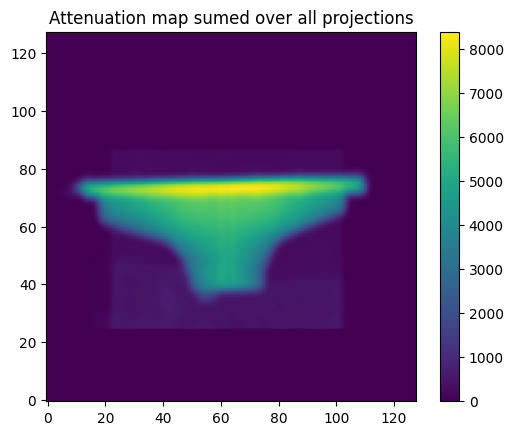

In [12]:
amap=x[0]
plt.imshow(amap.sum(axis=1),origin='lower')
plt.colorbar()
plt.title("Attenuation map sumed over all projections")

In [13]:
amap.shape

(128, 128, 128)

In [14]:
ndim,_,_=amap.shape
nangle=120
nrays=ndim

# Create (or load) Geometric Projection Matrix (pmatrix_geo)

*Only run for first time. This will generate the geometric matrix using a single cpu. This is a bit slow but it's only needed for the first time. The geometric projection matrix is saved using pk and can be loaded at a later stage.*

In [15]:
angles = np.linspace(0, 360, nangle, endpoint=False)
if not Path(PROJECT_PATH+'/pmatrix_geo.pk').exists():
  N = ndim  # image size: N x N
  pmatrix_geo = np.zeros((len(angles) * nrays, N * N))
  # --- Loop through each pixel and compute its projection ---
  for i in tqdm(range(N * N), desc="Building Radon matrix"):
      # Create image with 1 at pixel i, 0 elsewhere
      basis_img = np.zeros((N, N))
      row, col = divmod(i, N)
      basis_img[row, col] = 1.0

      # Compute projection (sinogram)
      sinogram_temp = radon(basis_img, theta=angles, circle=True)

      # Flatten the sinogram and store as column i
      pmatrix_geo[:, i] = sinogram_temp.T.flatten()

  print(f"Projection matrix shape: {pmatrix_geo.shape}")  # should be (num_angles*num_det_bins, N*N)
  pmatrix_geo=pmatrix_geo/pmatrix_geo.max()
  writedata(pmatrix_geo,PROJECT_PATH+'/pmatrix_geo.pk')
else:
  print('Loading pre-existing geometric projection matrix')
  pmatrix_geo=readdata(PROJECT_PATH+'/pmatrix_geo.pk')

Building Radon matrix: 100%|█████████████| 16384/16384 [02:16<00:00, 119.80it/s]


Projection matrix shape: (15360, 16384)


In [28]:
pmatrix_geo.shape

(15360, 16384)

# Create GATE source mask and attenuation map in raw format

In [29]:

def segment_attenuation_map_by_ranges(mu_map, material_ranges):
    """
    Segment attenuation map by user-specified ranges.

    Parameters
    ----------
    mu_map : np.ndarray
        Attenuation map in cm^-1
    material_ranges : list of tuples
        Each tuple is:
        (label, name, mu_min, mu_max)

        Use mu_max=None for open upper range.

    Returns
    -------
    seg : np.ndarray
        Integer-labelled segmentation map
    label_dict : dict
        label -> material name
    """
    mu_map = np.asarray(mu_map, dtype=float)
    seg = np.full(mu_map.shape, -1, dtype=np.int16)

    label_dict = {}

    for label, name, mu_min, mu_max in material_ranges:
        label_dict[label] = name

        if mu_max is None:
            mask = mu_map >= mu_min
        else:
            mask = (mu_map >= mu_min) & (mu_map < mu_max)

        seg[mask] = label

    return seg, label_dict

*Material segmentation used for the demonstration
In the present example, the attenuation map is converted into a small number of material classes using simple attenuation-coefficient ranges:*


In [30]:
material_ranges = [
    (0, "air",         0.00, 0.03),
    (1, "soft tissue", 0.03, 0.165),
    (2, "bone",        0.165, 0.185),
    (3, "dense",       0.185, 10.),
]

The attenuation map is stored using scaled integer values rather than directly as floating-point attenuation coefficients. Dividing by `1000.` provides values with units cm^-1



In [31]:

seg, label_dict = segment_attenuation_map_by_ranges(amap/1000., material_ranges)


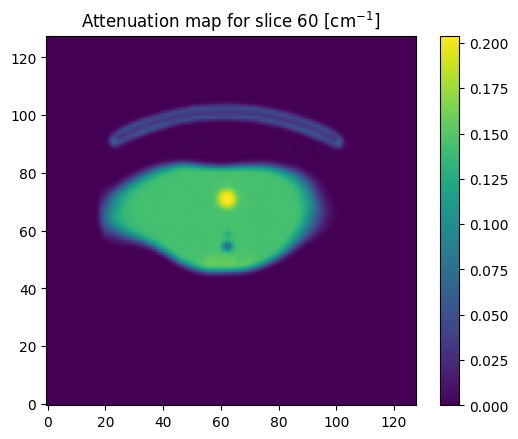

In [32]:
plt.imshow(amap[60]/1000,origin='lower')
plt.title(r"Attenuation map for slice 60 [cm$^{-1}$]")
plt.colorbar()

A mask is needed that will act as a source of gamma photons. For the particular example a threshold of above 85 is used (0.085 cm^-1)

Text(0.5, 1.0, 'Source mask for slice 60')

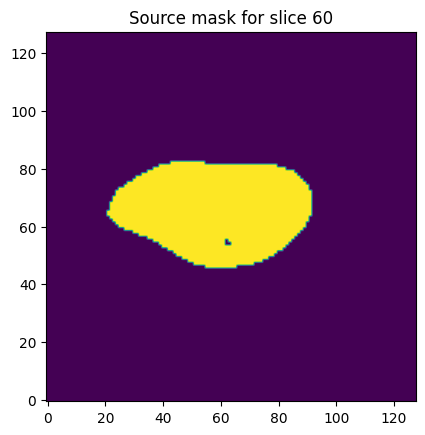

In [33]:
mask=amap>85.0
plt.imshow(mask[60],origin='lower')
plt.title(r"Source mask for slice 60")

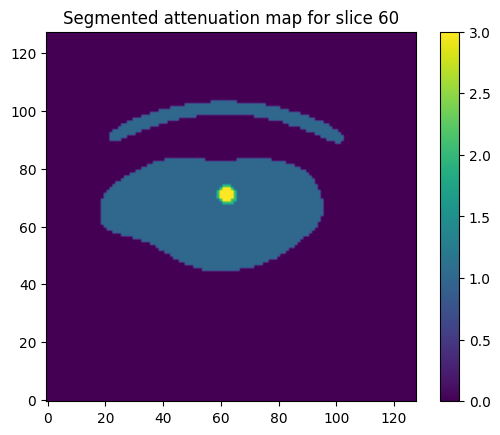

In [34]:
plt.imshow(seg[60],origin='lower')
plt.title(r"Segmented attenuation map for slice 60")
plt.colorbar()

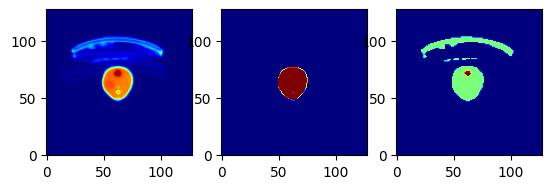

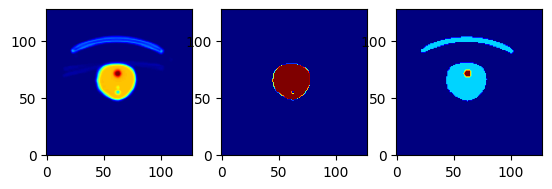

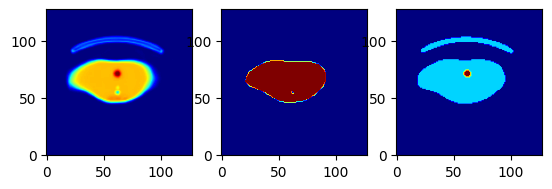

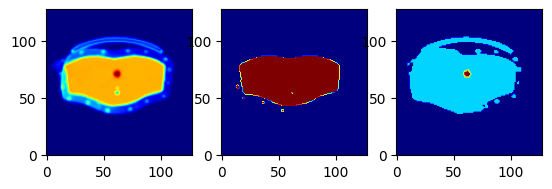

In [35]:
for i in range(40,75,10):
    plt.subplot(1,3,1)
    plt.imshow(amap[i],origin='lower',cmap='jet')
    plt.subplot(1,3,2)
    plt.imshow(mask[i],origin='lower',cmap='jet')
    plt.subplot(1,3,3)
    plt.imshow(seg[i],origin='lower',cmap='jet')
    plt.show()
    #plt.colorbar()

In [36]:

def write_mhd_raw(image: np.ndarray, out_prefix: str, spacing=(1.0, 1.0, 1.0), origin=(0.0, 0.0, 0.0)):
    """
    Save a 3D numpy array to MetaImage .mhd/.raw (float32, little-endian).
    - image: 3D array (Z, Y, X) or (Y, X) (will auto-promote to Z=1).
    - spacing: (dx, dy, dz) in mm (X, Y, Z order used in header).
    - origin:  (ox, oy, oz) in mm (X, Y, Z order used in header).
    """
    img = np.asarray(image)
    if img.ndim == 2:
        img = img[np.newaxis, ...]  # Z=1
    assert img.ndim == 3, "Image must be 2D or 3D"

    # GATE expects metaimage with Dimension = 3 and ElementSpacing = X Y Z
    # We'll store as float32, little-endian, raw.
    img = img.astype(np.float32, copy=False)

    z, y, x = img.shape
    out_prefix = Path(out_prefix)
    raw_path = out_prefix.with_suffix(".raw")
    mhd_path = out_prefix.with_suffix(".mhd")

    # Write raw binary
    img.tofile(raw_path)

    # Write header
    mhd = []
    mhd.append("ObjectType = Image")
    mhd.append("NDims = 3")
    mhd.append(f"DimSize = {x} {y} {z}")
    mhd.append("ElementType = MET_FLOAT")
    mhd.append(f"ElementSpacing = {spacing[0]} {spacing[1]} {spacing[2]}")  # X Y Z (mm)
    mhd.append(f"Position = {origin[0]} {origin[1]} {origin[2]}")           # optional, X Y Z
    mhd.append("BinaryData = True")
    mhd.append("BinaryDataByteOrderMSB = False")
    mhd.append("CompressedData = False")
    mhd.append(f"ElementDataFile = {raw_path.name}")

    mhd_path.write_text("\n".join(mhd))
    print(f"Wrote {mhd_path} and {raw_path}")



These commands save the segmented attenuation map and the source mask in `.mhd/.raw` format for use in GATE. The `spacing` argument specifies the physical voxel size, so that the geometry is correctly represented in the simulation.

In [37]:
write_mhd_raw(seg,PROJECT_PATH+"/mu_map",spacing=(PIXEL_SIZE,PIXEL_SIZE,PIXEL_SIZE))

Wrote mu_map.mhd and mu_map.raw


In [38]:
write_mhd_raw(mask,PROJECT_PATH+"/source_map",spacing=(PIXEL_SIZE,PIXEL_SIZE,PIXEL_SIZE))

Wrote source_map.mhd and source_map.raw


# Run GATE10 using gamma photons emitted from source_map with attenuation and scatter according to mu_map.

For each simulated angle, `GATE10.py` creates an output folder named

`output_<angle>`

inside `output_base`.

This folder contains the main GATE simulation outputs for that projection angle, including:

- **projection images** in `.mhd/.raw` format, generated separately for each detector head and for the selected energy window,
- **ROOT files** containing the digitizer outputs (hits, singles, and energy-window collections),
- **a statistics file** (`stats_dual.txt`) summarizing the simulation.

In the present configuration, the most important outputs are the projection images:

- `projection_h1_... .mhd`
- `projection_h2_... .mhd`

which correspond to the simulated projections recorded by the two detector heads.

These projection files are then used in the notebook to construct the GATE-based projection matrix.


Only angles smaller than **180°** are simulated because this is a **dual-head** setup. Each simulation angle produces two projections from detector heads placed **180° apart**, so the range **0°–180°** already covers the full acquisition. Simulating angles beyond **180°** would simply duplicate views already provided by the opposite head.

This will run one projection angle at a time (total of 120 for the examples used) It's a good idea to run this using multiple independent runs.


Main arguments:

- **`angle=a`**: projection angle of the dual-head camera system around the object.
- **`isotope="I123"`**: radionuclide used in the simulation; this determines the emitted gamma-ray spectrum and the corresponding energy windows.
- **`usecollimator=False`**: runs the simulation without a collimator. This is useful here for demonstration and for faster estimation of the system response.
- **`visualize=False`**: disables interactive visualisation during the simulation.
- **`PIXEL_SIZE=PIXEL_SIZE`**: voxel size of the input maps, used also to define the detector projection pixel size.
- **`ndim=ndim`**: number of detector pixels per image dimension, so the simulated projections are of size `ndim × ndim`.
- **`dtheta=0.0`**: angular spread of the emitted photons around the nominal detector direction. Here `0.0` means a single nominal projection direction is used.
- **`nthreads=1`**: number of CPU threads used by the simulation.
- **`activity=0.01`**: source activity in MBq assigned to each of the two voxel sources. A very low value is used here for demonstration in order to keep runtimes manageable.
- **`mu_map_path=.../mu_map.mhd`**: path to the voxelized attenuation map used to define the phantom materials in GATE.
- **`source_map_path=.../source_map.mhd`**: path to the voxelized source distribution used to define where activity is present.
- **`output_base=projectpath`**: directory where the output files for each angle are written.


## serial run

In [ ]:
for a in angles:
  if a<180. : #dual-head
    GATE10.run(
        angle=a,
        isotope="I123",
        usecollimator=False,
        visualize=False,
        PIXEL_SIZE=PIXEL_SIZE,
        ndim=ndim,
        dtheta=0.0,
        nthreads=1,
        activity=1,
        mu_map_path=PROJECT_PATH+"/mu_map.mhd",
        source_map_path=PROJECT_PATH+"/source_map.mhd",
        output_base=PROJECT_PATH,
    )

## or multi-thread

In [39]:
print(os.cpu_count())

14


In [66]:
import subprocess
import sys
import time
from pathlib import Path

angles_to_run = [a for a in angles if a < 180.0]
max_workers = 12

running = []
remaining = list(angles_to_run)

while remaining or running:
    # start new jobs until the worker limit is reached
    while remaining and len(running) < max_workers:
        a = remaining.pop(0)

        outdir = Path(PROJECT_PATH) / f"output_{a}"
        outdir.mkdir(parents=True, exist_ok=True)

        logfile = open(outdir / "run.log", "w")

        cmd = [
            sys.executable,
            "-c",
            (
                "import sys; "
                f"sys.path.append(r'{PROJECT_PATH}'); "
                "import GATE10; "
                f"GATE10.run(angle={float(a)}, "
                "isotope='I123', "
                "usecollimator=False, "
                "visualize=False, "
                f"PIXEL_SIZE={PIXEL_SIZE}, "
                f"ndim={ndim}, "
                "dtheta=0.0, "
                "nthreads=1, "
                "activity=3, "
                f"mu_map_path=r'{PROJECT_PATH}/mu_map.mhd', "
                f"source_map_path=r'{PROJECT_PATH}/source_map.mhd', "
                f"output_base=r'{PROJECT_PATH}')"
            )
        ]

        print(f"Starting angle {a}")
        p = subprocess.Popen(cmd, stdout=logfile, stderr=logfile)
        running.append((a, p, logfile))

    # check running jobs
    still_running = []
    for a, p, logfile in running:
        ret = p.poll()
        if ret is None:
            still_running.append((a, p, logfile))
        else:
            logfile.close()
            print(f"Angle {a} finished with return code {ret}")
    running = still_running

    # avoid hammering the CPU with constant polling
    time.sleep(1)

print("All runs completed.")

Starting angle 0.0
Starting angle 3.0
Starting angle 6.0
Starting angle 9.0
Starting angle 12.0
Starting angle 15.0
Starting angle 18.0
Starting angle 21.0
Starting angle 24.0
Starting angle 27.0
Starting angle 30.0
Starting angle 33.0
Angle 0.0 finished with return code 0
Starting angle 36.0
Angle 3.0 finished with return code 0
Starting angle 39.0
Angle 6.0 finished with return code 0
Starting angle 42.0
Angle 12.0 finished with return code 0
Starting angle 45.0
Angle 9.0 finished with return code 0
Starting angle 48.0
Angle 15.0 finished with return code 0
Starting angle 51.0
Angle 21.0 finished with return code 0
Starting angle 54.0
Angle 18.0 finished with return code 0
Starting angle 57.0
Angle 24.0 finished with return code 0
Starting angle 60.0
Angle 33.0 finished with return code 0
Starting angle 63.0
Angle 27.0 finished with return code 0
Angle 30.0 finished with return code 0
Starting angle 66.0
Starting angle 69.0
Angle 36.0 finished with return code 0
Starting angle 72.0
A

# Generate projections from GATE output (if not done)



In [86]:

isotope = "I123"
analysisdirs=[PROJECT_PATH]

outname=PROJECT_PATH+'/projections_ideal_NC.pk'

dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith(
    "output_")]

angles = sorted(
    [float(d.split("_")[1]) for d in dirs]
)

print(angles)
print(len(angles))


def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return



projections = np.zeros((2*len(angles), ndim, ndim, ndim), dtype=np.float32)
icount = 0
for angle in angles:
    print('processing angle ',angle)
    for analysisdir in analysisdirs:

        outdir = analysisdir+f"/output_{angle}/"
        f_h1 = uproot.open(outdir + f"{isotope}_h1.root")
        tree1 = f_h1["Hits_h1;1"]
        arr1 = tree1.arrays(library="ak")
        pid1 = ak.to_numpy(arr1["ParentID"])
        m1 = (pid1 == 0)
        ex1 = ak.to_numpy(arr1["TrackVertexPosition_X"])
        ex1=ex1[m1]
        ey1 = ak.to_numpy(arr1["TrackVertexPosition_Y"])
        ey1=ey1[m1]
        ez1 = ak.to_numpy(arr1["TrackVertexPosition_Z"])
        ez1=ez1[m1]


        # --- Head 2 ROOT ---
        f_h2 = uproot.open(outdir + f"{isotope}_h2.root")
        tree2 = f_h2["Hits_h2;1"]
        arr2 = tree2.arrays(library="ak")
        pid2 = ak.to_numpy(arr2["ParentID"])
        m2 = (pid2 == 0)
        ex2 = ak.to_numpy(arr2["TrackVertexPosition_X"])
        ex2=ex2[m2]
        ey2 = ak.to_numpy(arr2["TrackVertexPosition_Y"])
        ey2=ey2[m2]
        ez2 = ak.to_numpy(arr2["TrackVertexPosition_Z"])
        ez2=ez2[m2]

        phantom_width = ndim * PIXEL_SIZE
        x_edges = np.linspace(-phantom_width/2, phantom_width/2,  ndim + 1)
        y_edges = np.linspace(-phantom_width/2, phantom_width/2, ndim + 1)
        z_edges = np.linspace(-phantom_width/2, phantom_width/2, ndim + 1)
        # ================== projection matrix =========================
        samples_front = np.vstack([ez1, ey1, ex1]).T  # (N,3) as (z, x, y)
        projection1, _ = np.histogramdd(
            samples_front,
            bins=(z_edges, y_edges, x_edges)
        )
        samples_rear = np.vstack([ez2, ey2, ex2]).T
        projection2, _ = np.histogramdd(
            samples_rear,
            bins=(z_edges, y_edges, x_edges)
        )
        projections[icount,             :, :, :] += projection2  # h2
        projections[icount+len(angles), :, :, :] += projection1  # h1

        icount += 1
#    break
projections=projections[::-1]

writedata(projections,outname)


[0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0, 27.0, 30.0, 33.0, 36.0, 39.0, 42.0, 45.0, 48.0, 51.0, 54.0, 57.0, 60.0, 63.0, 66.0, 69.0, 72.0, 75.0, 78.0, 81.0, 84.0, 87.0, 90.0, 93.0, 96.0, 99.0, 102.0, 105.0, 108.0, 111.0, 114.0, 117.0, 120.0, 123.0, 126.0, 129.0, 132.0, 135.0, 138.0, 141.0, 144.0, 147.0, 150.0, 153.0, 156.0, 159.0, 162.0, 165.0, 168.0, 171.0, 174.0, 177.0]
60
processing angle  0.0
processing angle  3.0
processing angle  6.0
processing angle  9.0
processing angle  12.0
processing angle  15.0
processing angle  18.0
processing angle  21.0
processing angle  24.0
processing angle  27.0
processing angle  30.0
processing angle  33.0
processing angle  36.0
processing angle  39.0
processing angle  42.0
processing angle  45.0
processing angle  48.0
processing angle  51.0
processing angle  54.0
processing angle  57.0
processing angle  60.0
processing angle  63.0
processing angle  66.0
processing angle  69.0
processing angle  72.0
processing angle  75.0
processing angle  78

# Application to a specific section

## Create 2D projection matrix

## Projection-matrix model used here

Two projection-matrix models are considered:

- **Geometric matrix (`pmatrix_geo`)**: constructed from a simplified geometric forward model.
- **GATE-based corrected matrix**: obtained by combining the geometric model with Monte Carlo-derived corrections based on attenuation and acquisition physics.

This allows a direct comparison between a simplified system model and a more realistic Monte Carlo-informed model.

In [28]:
projections=readdata('/content/drive/MyDrive/PERSPECT/projections_ideal_NC.pk')

In [87]:
nslice=60

In [88]:
pmatrix_gate_NC=np.zeros((nangle,nrays,ndim,ndim))
for iang in range(nangle):
    for iray in range(nrays):
        pmatrix_gate_NC[iang,iray,:,:]=(pmatrix_geo.reshape(nangle,nrays,ndim,ndim))[iang,iray,:,:]*\
        projections[iang,nslice,:,:] #.sum(axis=0)
#pmatrix_gate_datscan_WC=pmatrix_gate_datscan_WC/pmatrix_gate_datscan_WC.max()


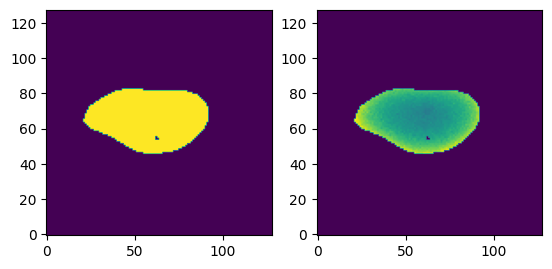

In [89]:
plt.subplot(1,2,1)
plt.imshow(mask[nslice],origin='lower')
plt.subplot(1,2,2)
plt.imshow(projections.sum(axis=0)[nslice,:,:],origin='lower')

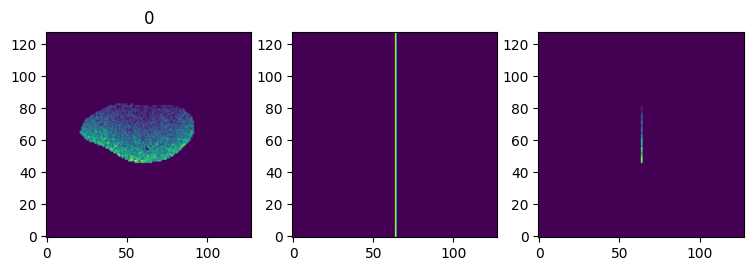

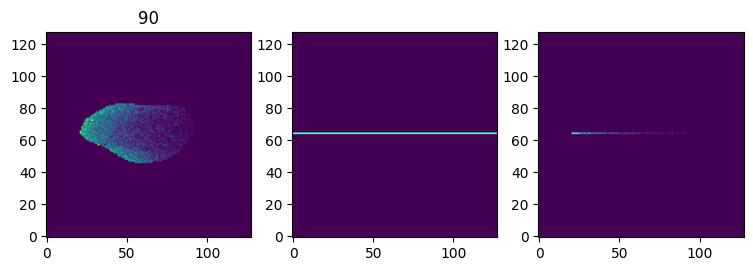

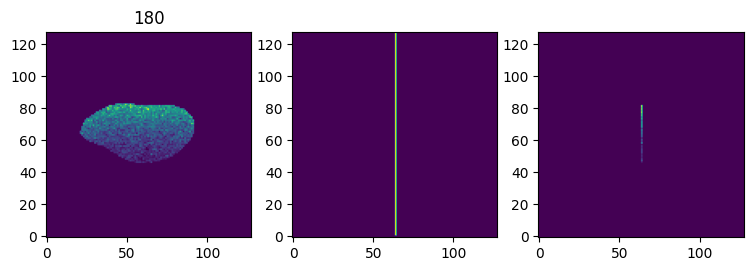

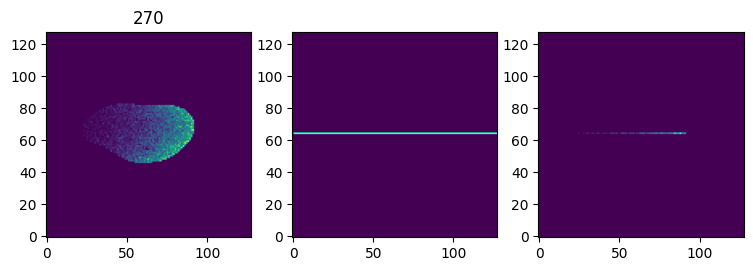

In [90]:
for i in range(nangle):
    if i % 30 ==0:
        plt.figure(figsize=(9,4))
        plt.subplot(1,3,1)
        plt.imshow(projections[i,nslice,:,:],origin='lower')
        plt.title(str(i*3))
        plt.subplot(1,3,2)
        plt.imshow(pmatrix_geo.reshape(nangle,nrays,ndim,ndim)[i,64,:,:],origin='lower')
        plt.subplot(1,3,3)
        plt.imshow(pmatrix_gate_NC[i,64,:,:],origin='lower')
        plt.show()
#plt.imshow(projection2)

In [72]:
filepath2=PROJECT_PATH+"/TOMOCT_EM001_DS.dcm"

In [73]:
sinograms=load_dicom(filepath2)[0]

In [74]:
sinograms.shape

(480, 128, 128)

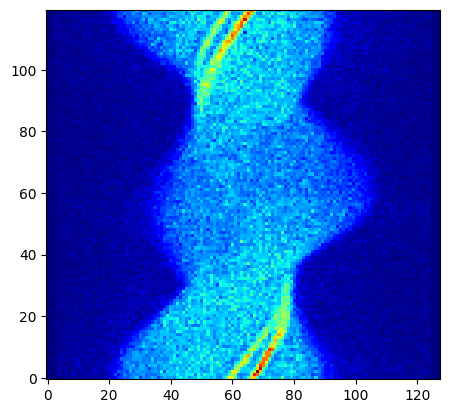

In [75]:
sinogram=sinograms[:120,nslice,:]
plt.imshow(sinogram,origin='lower',cmap='jet')

## Define MLEM and load to gpu

In [76]:

def normimg(img):
    return img/np.nanmean(img)
def printProgressBar(i,max,postText):
    n_bar =40 #size of progress bar
    j= i/max
    sys.stdout.write('\r')
    sys.stdout.write(f"[{'=' * int(n_bar * j):{n_bar}s}] {int(100 * j)}%  {postText}")
    sys.stdout.flush()

def mlem_reconstruction(
    PM,
    sinogram_gpu,
    ndim,
    n_iter=10,
    epsilon=1e-10,
    kernel_params=[],
    *,
    # Optional physical constraints / safeguards
    enforce_positivity=True,          # activity must be >= 0
    mask_outside_fov=True,            # voxels with zero sensitivity forced to 0
    use_proper_sensitivity=True,      # replaces (projection_sum + 1) with max(projection_sum, eps)
    preserve_total_counts=False,       # renormalize image each iter to match total measured counts
    count_relax=0.2
):
    # Sensitivity (a.k.a. normalization image): s = P^T 1
    projection_sum = tf.reduce_sum(PM, axis=0)  # shape: (ndim*ndim,)

    # Optional FOV mask: voxels that are never "seen" by the system matrix
    if mask_outside_fov:
        fov_mask = tf.cast(projection_sum > 0.0, tf.float32)  # 1 where observable
    else:
        fov_mask = tf.ones_like(projection_sum, dtype=tf.float32)

    # Safer denominator: do NOT bias with +1; only protect division by zero
    if use_proper_sensitivity:
        denom = tf.maximum(projection_sum, tf.constant(epsilon, tf.float32))
    else:
        # Keeps your original behavior (not recommended physically)
        denom = projection_sum + 1.0

    def gaussian_kernel(size, sigma):
        ax = np.linspace(-(size // 2), size // 2, size)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-0.5 * (xx**2 + yy**2) / sigma**2)
        kernel /= np.sum(kernel)
        return kernel

    if len(kernel_params) > 0:
        kernel = gaussian_kernel(kernel_params[0], kernel_params[1])

    # Initial image (positive)
    reconstructed_image = tf.Variable(np.ones(ndim * ndim), dtype=tf.float32)

    # Apply FOV mask at init if enabled
    if mask_outside_fov:
        reconstructed_image.assign(reconstructed_image * fov_mask)

    start_time = time.time()
    chi2_loss = -1.0

    # For optional global renormalization (heuristic; only enable if you want it)
    y_sum = tf.reduce_sum(tf.cast(sinogram_gpu, tf.float32))

    for iter in range(n_iter):
        printProgressBar(iter, n_iter, '' + str(chi2_loss))

        # Optional smoothing (heuristic regularization)
        if len(kernel_params) > 0:
            rimage = reconstructed_image.numpy()
            temp = convolve(np.reshape(rimage, (ndim, ndim)), kernel, mode='reflect').ravel()
            reconstructed_image.assign(temp)

        # Physical constraint: non-negativity
        if enforce_positivity:
            reconstructed_image.assign(tf.maximum(reconstructed_image, 0.0))

        # Physical constraint: zero outside FOV (voxels with zero sensitivity)
        if mask_outside_fov:
            reconstructed_image.assign(reconstructed_image * fov_mask)

        # Forward projection
        forward_projection = tf.linalg.matvec(PM, reconstructed_image)
        forward_projection = tf.maximum(forward_projection, tf.constant(epsilon, tf.float32))

        # Compute ratio
        ratio = sinogram_gpu / forward_projection

        # Back-projection
        back_projection = tf.linalg.matvec(tf.transpose(PM), ratio)

        # MLEM update with correct/safe denominator
        reconstructed_image.assign(reconstructed_image * (back_projection / denom))

        # Optional global renormalization to match total measured counts
        # (heuristic; can be useful if your PM is not strictly probability-normalized)
        if preserve_total_counts:
            fp_sum = tf.reduce_sum(tf.linalg.matvec(PM, reconstructed_image))
            fp_sum = tf.maximum(fp_sum, tf.constant(epsilon, tf.float32))
            alpha = y_sum / fp_sum
            # softened update: alpha**count_relax
            reconstructed_image.assign(reconstructed_image * tf.pow(alpha, count_relax))
        # Monitor (your chi2-like metric)
        chi2_loss = tf.reduce_mean((forward_projection - sinogram_gpu) ** 2 / (sinogram_gpu + epsilon))

    # Final loss
    forward_projection_final = tf.linalg.matvec(PM, reconstructed_image)
    chi2_loss = tf.reduce_mean((forward_projection_final - sinogram_gpu) ** 2 / (sinogram_gpu + epsilon))

    reconstructed_image = tf.reshape(reconstructed_image, (ndim, ndim))
    cpu_time = time.time() - start_time

    print()
    print('final chi2_loss =', chi2_loss.numpy())
    return reconstructed_image, chi2_loss, cpu_time




In [77]:
pmatrix_geo.shape

(15360, 16384)

In [78]:
pmatrix_geo_gpu = tf.constant(pmatrix_geo, dtype=tf.float32)

In [79]:
pmatrix_gate_NC=pmatrix_gate_NC.reshape(nangle*nrays,ndim**2)
pmatrix_gate_NC=pmatrix_gate_NC/pmatrix_gate_NC.max()

In [80]:
pmatrix_gate_NC_gpu=tf.constant(pmatrix_gate_NC,dtype=tf.float32)

In [81]:
sinogram_gpu = tf.constant(sinogram.ravel(), dtype=tf.float32)

## Reconstruction without correction

In [82]:
reconstructed_image0_MLEM,error,t = mlem_reconstruction(pmatrix_geo_gpu,sinogram_gpu,ndim,n_iter=100,epsilon=0.0001,kernel_params=[])
print('time=',t)

[======================================= ] 99%  tf.Tensor(1097.0276, shape=(), dtype=float32)
final chi2_loss = 1094.9451
time= 3.7102010250091553


Text(0.5, 1.0, 'Reconstructed image')

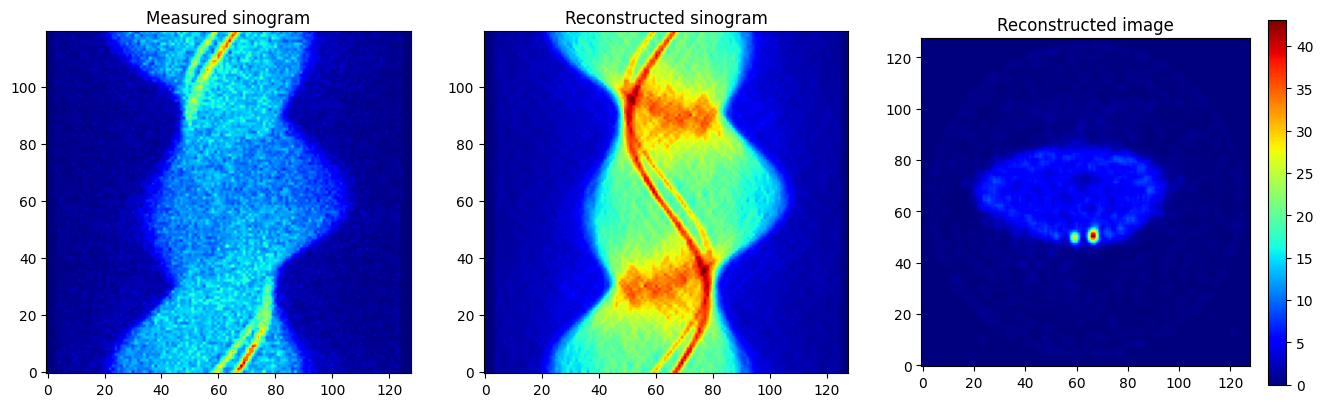

In [83]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
vmax=200
plt.imshow(sinogram,cmap='jet',origin='lower') #,vmax=vmax)
plt.title('Measured sinogram')
plt.subplot(1,3,2)
rsinogram0=np.dot(pmatrix_geo.reshape(nrays*nangle,ndim*ndim),(reconstructed_image0_MLEM.numpy()).ravel())
r=rsinogram0.mean()
plt.title('Reconstructed sinogram')
#print(r)
plt.imshow(rsinogram0.reshape(nangle,nrays),cmap='jet',origin='lower') #,vmax=vmax)
plt.subplot(1,3,3)
plt.imshow(smear(normimg(reconstructed_image0_MLEM),1),cmap='jet',origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Reconstructed image')

## Reconstruction with GATE correction

In [91]:
reconstructed_image1_MLEM,error,t = mlem_reconstruction(pmatrix_gate_NC_gpu,sinogram_gpu,ndim,n_iter=100,epsilon=0.0001,kernel_params=[])
print('time=',t)

[======================================= ] 99%  tf.Tensor(3.8703048, shape=(), dtype=float32)
final chi2_loss = 3.8698313
time= 3.661954164505005


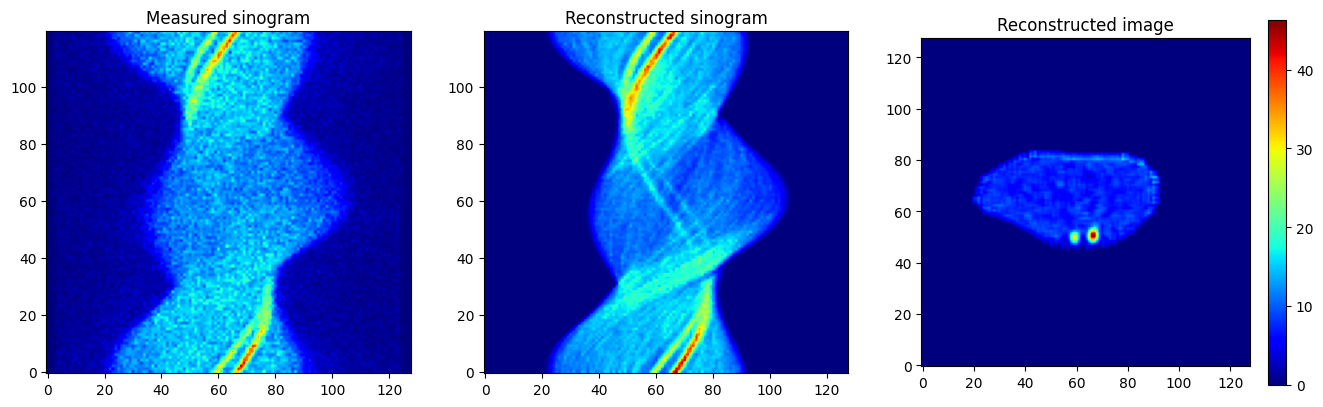

In [92]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
vmax=200
plt.imshow(sinogram,cmap='jet',origin='lower') #,vmax=vmax)
plt.title('Measured sinogram')
plt.subplot(1,3,2)
rsinogram1=np.dot(pmatrix_gate_NC.reshape(nrays*nangle,ndim*ndim),(reconstructed_image0_MLEM.numpy()).ravel())
r=rsinogram1.mean()
plt.title('Reconstructed sinogram')
#print(r)
plt.imshow(rsinogram1.reshape(nangle,nrays),cmap='jet',origin='lower') #,vmax=vmax)
plt.subplot(1,3,3)
plt.imshow(smear(normimg(reconstructed_image1_MLEM),1),cmap='jet',origin='lower')
plt.title('Reconstructed image')
plt.colorbar(fraction=0.05)